In [1]:
!git clone https://github.com/rashmi06an/EdTech-Grading-Assistant.git
%cd EdTech-Grading-Assistant

Cloning into 'EdTech-Grading-Assistant'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 102 (delta 31), reused 78 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 2.85 MiB | 6.63 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/Users/rashmianand/Desktop/EdTech-Grading-Assistant/notebooks/EdTech-Grading-Assistant


In [3]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add root project folder to sys.path so we can import src.loader
sys.path.append(os.path.abspath(".."))
from src.loader import load_mnist

# Set style configuration for visual excellence
sns.set_theme(style="white")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Arial", "Helvetica"]
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.linewidth"] = 0.8

print("All libraries and custom loader imported successfully!")

Matplotlib is building the font cache; this may take a moment.


All libraries and custom loader imported successfully!


In [4]:
# Load the dataset using the custom loader module
X, y = load_mnist(version=1, as_frame=False, cast_to_int=True)

2026-07-21 12:28:59,153 - INFO - Bypassed SSL context verification for OpenML dataset retrieval.
2026-07-21 12:28:59,155 - INFO - Fetching MNIST dataset (mnist_784) from OpenML. This might take a moment...
2026-07-21 12:29:07,079 - INFO - Target labels cast to 8-bit integers.
2026-07-21 12:29:07,080 - INFO - Successfully loaded MNIST. X shape: (70000, 784), y shape: (70000,)


In [5]:
print(f"Feature matrix shape (X): {X.shape}")
print(f"Target vector shape (y) : {y.shape}")
print(f"Data type of features  : {X.dtype}")
print(f"Data type of target    : {y.dtype}")
print(f"Minimum pixel value     : {X.min()}")
print(f"Maximum pixel value     : {X.max()}")

Feature matrix shape (X): (70000, 784)
Target vector shape (y) : (70000,)
Data type of features  : float64
Data type of target    : int8
Minimum pixel value     : 0.0
Maximum pixel value     : 255.0


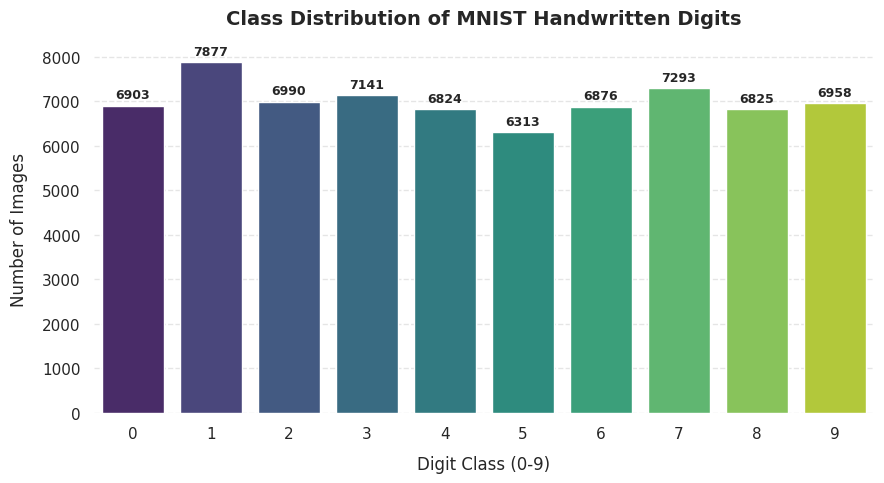

In [6]:
# Calculate class counts
class_counts = pd.Series(y).value_counts().sort_index()

# Plot the distribution using a clean Seaborn barplot
plt.figure(figsize=(9, 5))
colors = sns.color_palette("viridis", n_colors=10)
sns.barplot(x=class_counts.index, y=class_counts.values, palette=colors, hue=class_counts.index, legend=False)

plt.title("Class Distribution of MNIST Handwritten Digits", fontsize=14, pad=15, weight="bold")
plt.xlabel("Digit Class (0-9)", fontsize=12, labelpad=10)
plt.ylabel("Number of Images", fontsize=12, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(left=True, bottom=True)

for index, value in enumerate(class_counts.values):
    plt.text(index, value + 100, str(value), ha='center', va='bottom', fontsize=9, weight="semibold")

plt.tight_layout()
plt.show()

In [7]:
def reshape_digit(feature_row):
    """
    Reshapes a flat 784-element feature vector into a 28x28 numpy array.
    """
    return feature_row.reshape(28, 28)

# Select a sample index to visualize (e.g., sample 0)
sample_index = 0
digit_image = reshape_digit(X[sample_index])
digit_label = y[sample_index]

print(f"Original shape of row: {X[sample_index].shape}")
print(f"Reshaped dimensions  : {digit_image.shape}")
print(f"Corresponding label  : {digit_label}")

Original shape of row: (784,)
Reshaped dimensions  : (28, 28)
Corresponding label  : 5


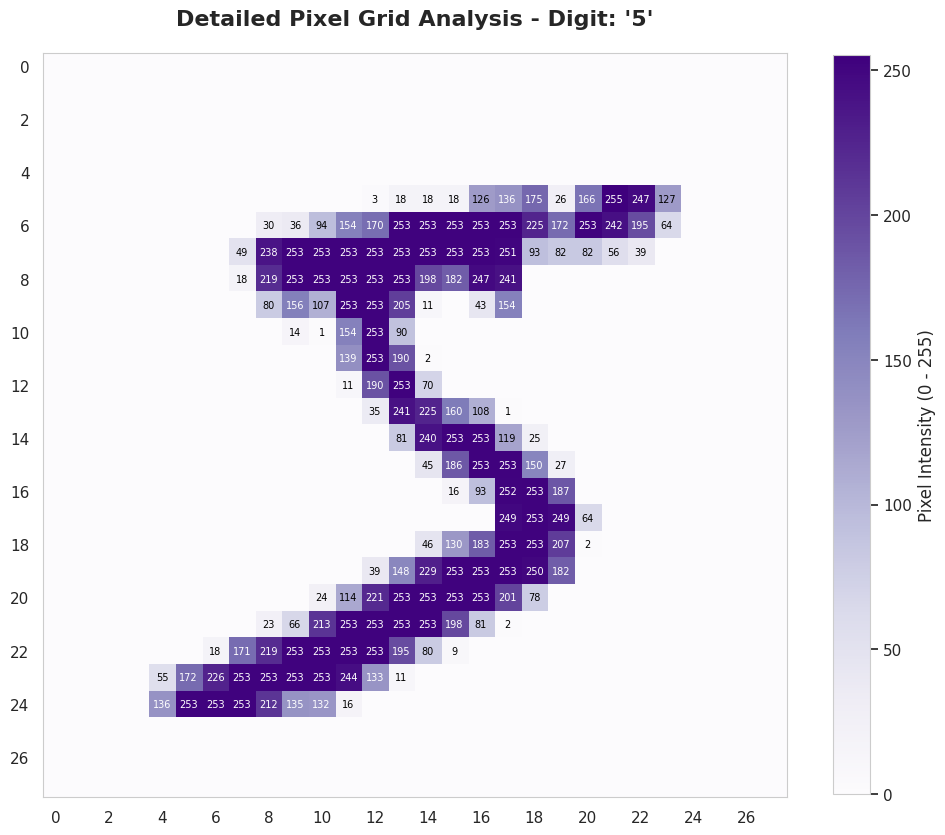

In [8]:
plt.figure(figsize=(12, 12))
# Render using a premium blue-purple sequential colormap ('Purples')
plt.imshow(digit_image, cmap='Purples', interpolation='nearest')
plt.colorbar(label='Pixel Intensity (0 - 255)', shrink=0.8)
plt.title(f"Detailed Pixel Grid Analysis - Digit: '{digit_label}'", fontsize=16, pad=20, weight='bold')

# Annotate each pixel with its integer value if it exceeds a threshold (for readability)
for i in range(28):
    for j in range(28):
        val = int(digit_image[i, j])
        if val > 0:
            color = "white" if val > 128 else "black"
            plt.text(j, i, str(val), ha='center', va='center', color=color, fontsize=7)

plt.xticks(np.arange(0, 28, 2))
plt.yticks(np.arange(0, 28, 2))
plt.grid(False)
plt.show()

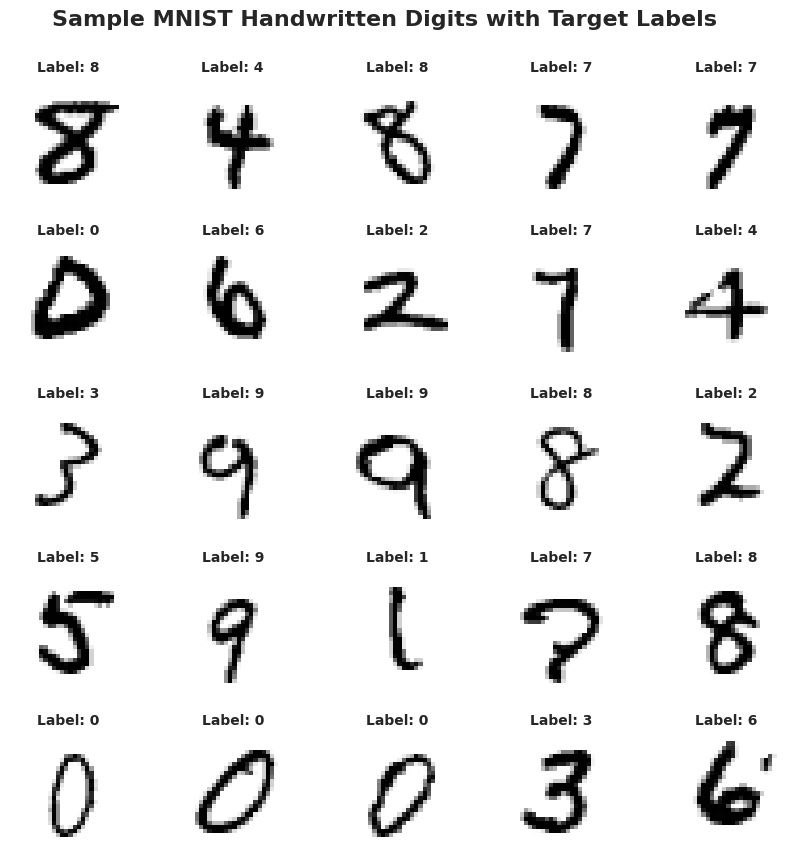

In [9]:
np.random.seed(42)  # For reproducibility
random_indices = np.random.choice(len(X), size=25, replace=False)

fig, axes = plt.subplots(5, 5, figsize=(10, 10))
fig.suptitle("Sample MNIST Handwritten Digits with Target Labels", fontsize=16, weight='bold', y=0.95)

for idx, ax in zip(random_indices, axes.ravel()):
    image = reshape_digit(X[idx])
    label = y[idx]

    # Display image using 'binary' (white background, black stroke)
    ax.imshow(image, cmap='binary')
    ax.set_title(f"Label: {label}", fontsize=10, weight='semibold')
    ax.axis('off')

plt.subplots_adjust(hspace=0.4, wspace=0.4)
plt.show()

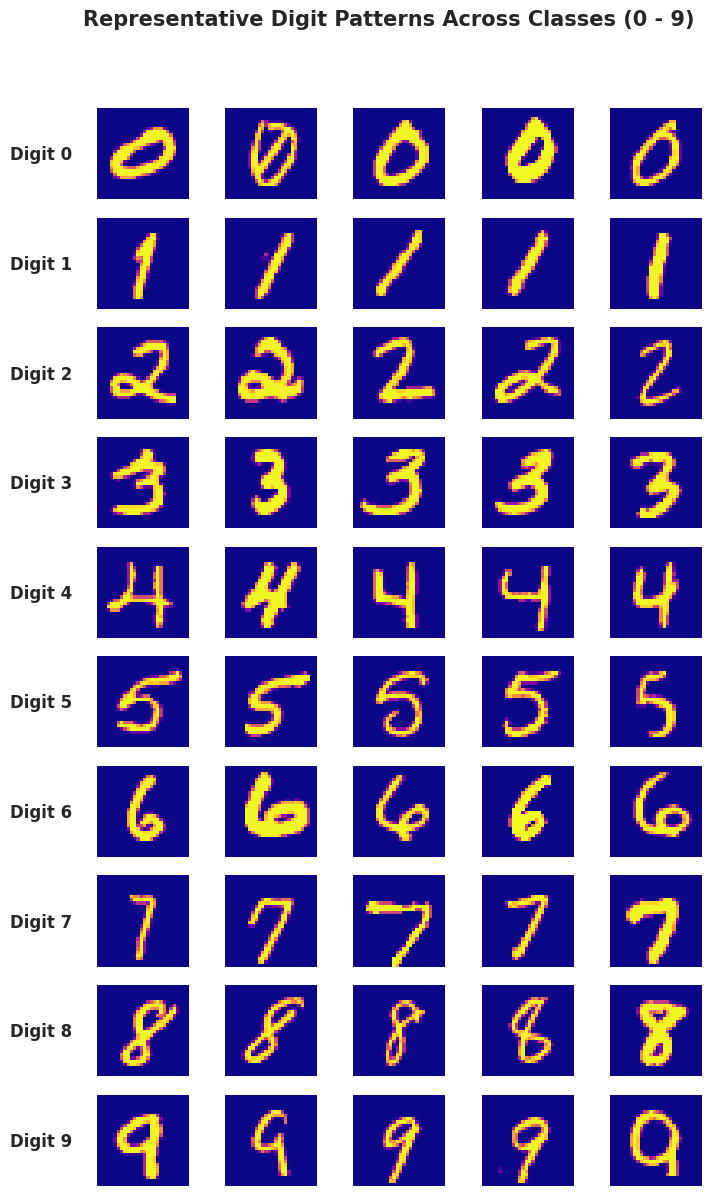

In [10]:
fig, axes = plt.subplots(10, 5, figsize=(8, 14))

for digit in range(10):
    # Get indices of all images matching this specific digit
    digit_indices = np.where(y == digit)[0]
    # Sample 5 indices
    selected_indices = np.random.choice(digit_indices, size=5, replace=False)

    for col, idx in enumerate(selected_indices):
        ax = axes[digit, col]
        image = reshape_digit(X[idx])
        ax.imshow(image, cmap='plasma')  # Use a vibrant plasma colormap for contrast
        ax.axis('off')

        # Add row labels to the first column
        if col == 0:
            ax.text(-8, 14, f"Digit {digit}", ha='right', va='center', fontsize=12, weight='bold')

plt.suptitle("Representative Digit Patterns Across Classes (0 - 9)", fontsize=15, weight='bold', y=0.95)
plt.subplots_adjust(hspace=0.2, wspace=0.2)
plt.show()

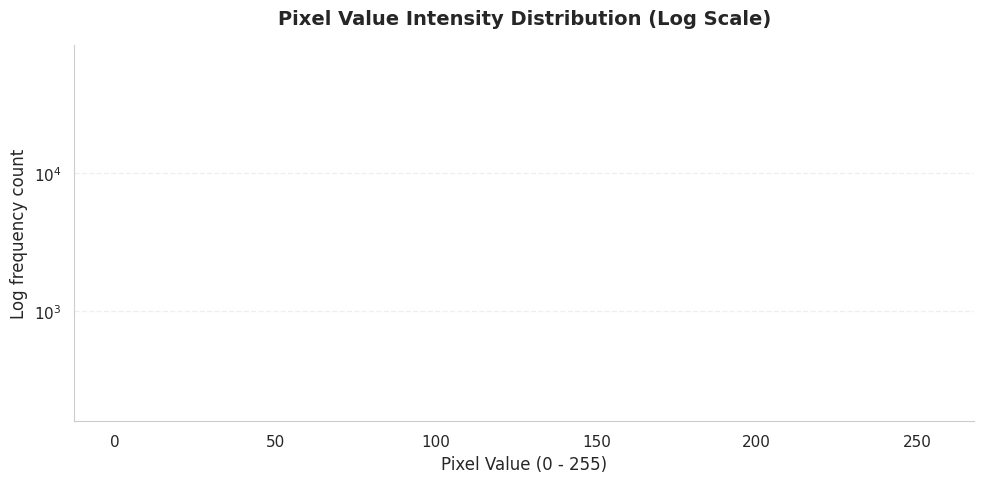

In [11]:
plt.figure(figsize=(10, 5))
# Sample 100 random images and flatten their pixel values into a single array
sample_pixels = X[np.random.choice(len(X), 100, replace=False)].ravel()

sns.histplot(sample_pixels, bins=30, kde=False, color='#4A148C', edgecolor='white', log_scale=(False, True))
plt.title("Pixel Value Intensity Distribution (Log Scale)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Pixel Value (0 - 255)", fontsize=12)
plt.ylabel("Log frequency count", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()